#**TUGAS BESAR MACHINE LEARNIING**

## **Analisis Faktor Pembeda Mahasiswa Aktif dan Nonaktif Menggunakan Algoritma Gradient Boosting dengan Strategi Penanganan Ketidakseimbangan Data**

Notebook ini dibuat untuk menganalisis faktor-faktor yang membedakan mahasiswa **Aktif** dan **Nonaktif** berdasarkan dataset **Predict Students' Dropout and Academic Success** dari **UCI Machine Learning Repository**.

Target asli dataset:
- Graduate
- Enrolled
- Dropout

Target penelitian ini:
- **Aktif** = Enrolled
- **Nonaktif** = Graduate + Dropout

Fokus penelitian bukan hanya memprediksi status mahasiswa, tetapi mengidentifikasi faktor-faktor yang paling membedakan mahasiswa yang masih berada dalam siklus akademik dengan mahasiswa yang sudah keluar dari status aktif akademik.

### **Latar Belakang**
Perguruan tinggi membutuhkan sistem analisis akademik yang mampu membantu memahami kondisi mahasiswa berdasarkan data. Informasi mengenai status keaktifan mahasiswa penting karena dapat digunakan sebagai dasar penyusunan strategi akademik, pemberian pendampingan, serta evaluasi proses pembelajaran. Dengan memanfaatkan teknik machine learning, pola-pola yang terdapat pada data mahasiswa dapat digunakan untuk memprediksi status akademik secara lebih cepat dan objektif.

Dataset yang digunakan dalam penelitian ini berasal dari UCI Machine Learning Repository yang mengelompokkan mahasiswa ke dalam tiga status, yaitu Graduate, Enrolled, dan Dropout. Pada penelitian ini, target diubah menjadi klasifikasi biner dengan mengelompokkan Enrolled sebagai mahasiswa Aktif, sedangkan Graduate dan Dropout sebagai mahasiswa Nonaktif. Perubahan ini dilakukan agar penelitian lebih fokus pada identifikasi mahasiswa yang masih aktif dalam proses akademik dibandingkan mahasiswa yang sudah tidak aktif. Selain itu, distribusi data yang tidak seimbang menyebabkan diperlukan teknik penanganan imbalance seperti Class Weight, Tomek Links, ENN, dan SMOTE. Selanjutnya, algoritma Gradient Boosting digunakan untuk membangun model klasifikasi dan dievaluasi menggunakan metrik Accuracy, Precision, Recall, dan F1-Score guna memperoleh performa model yang optimal.


### **Gap Penelitian**

Penelitian sebelumnya mengenai dataset Predict Students Dropout and Academic Success umumnya berfokus pada prediksi tiga status akademik mahasiswa, yaitu Graduate, Enrolled, dan Dropout. Berbagai algoritma machine learning telah digunakan, seperti Decision Tree, Random Forest, Support Vector Machine (SVM), XGBoost, dan Gradient Boosting untuk memperoleh performa prediksi yang tinggi.

Gap penelitian yang diambil dalam tugas ini adalah:

1. **Perubahan fokus target penelitian**  
   Target asli yang terdiri dari tiga kelas (Graduate, Enrolled, dan Dropout) diubah menjadi dua kelas, yaitu Aktif dan Nonaktif. Mahasiswa berstatus Enrolled dikategorikan sebagai Aktif, sedangkan Graduate dan Dropout digabungkan sebagai Nonaktif. Pendekatan ini memberikan perspektif yang berbeda karena fokus penelitian diarahkan pada identifikasi keaktifan mahasiswa dalam proses akademik.

2. **Perbandingan beberapa teknik penanganan data tidak seimbang**  
  Setelah transformasi target dilakukan, distribusi data menjadi tidak seimbang karena jumlah mahasiswa Aktif lebih sedikit dibandingkan Nonaktif. Oleh karena itu, penelitian ini tidak hanya menggunakan model Gradient Boosting standar, tetapi juga membandingkan beberapa teknik penanganan imbalance, yaitu Class Weight, Tomek Links, Edited Nearest Neighbours (ENN), dan SMOTE untuk mengetahui metode yang memberikan performa terbaik.

3. **Fokus pada evaluasi kelas minoritas**  
   Sebagian penelitian lebih menekankan pada nilai accuracy sebagai indikator utama performa model. Pada penelitian ini, evaluasi dilakukan menggunakan Accuracy, Precision, Recall, dan terutama Macro F1-Score agar kemampuan model dalam mengenali kedua kelas, khususnya kelas minoritas, dapat diukur secara lebih seimbang.

4. **Interpretasi hasil model**  
 Selain membangun model prediksi, penelitian ini juga melakukan interpretasi model menggunakan SHAP (SHapley Additive Explanations). Analisis ini bertujuan untuk mengidentifikasi fitur-fitur yang paling berpengaruh terhadap status keaktifan mahasiswa sehingga hasil prediksi tidak hanya akurat, tetapi juga mudah dijelaskan dan dipahami.

### **Tujuan**
### Tujuan Penelitian

Berdasarkan latar belakang dan gap penelitian yang telah diidentifikasi, tujuan penelitian ini adalah:

1. Mengembangkan model klasifikasi untuk memprediksi status mahasiswa menjadi dua kategori, yaitu **Aktif (Enrolled)** dan **Nonaktif (Graduate dan Dropout)** menggunakan algoritma **Gradient Boosting**.

2. Menganalisis pengaruh penerapan berbagai teknik penanganan data tidak seimbang, yaitu **Class Weight**, **Tomek Links**, **Edited Nearest Neighbours (ENN)**, dan **SMOTE**, terhadap performa model klasifikasi.

3. Membandingkan performa model Gradient Boosting sebelum dan sesudah penerapan teknik penanganan imbalance berdasarkan metrik **Accuracy**, **Precision**, **Recall**, dan **Macro F1-Score**.

4. Mengidentifikasi teknik penanganan imbalance yang menghasilkan performa terbaik dalam mengklasifikasikan status keaktifan mahasiswa.

5. Menginterpretasikan hasil prediksi model menggunakan **SHAP (SHapley Additive Explanations)** untuk mengetahui faktor-faktor yang paling berpengaruh terhadap status keaktifan mahasiswa.


### **Metode yang digunakan**
Metode utama yang digunakan adalah Gradient Boosting Classifier. Metode ini dipilih karena termasuk algoritma ensemble berbasis decision tree yang bekerja secara bertahap dengan memperbaiki kesalahan prediksi dari model sebelumnya.

In [1]:
# =========================================================
# SEL 1: SETUP ENVIRONMENT & INSTALL LIBRARY
# =========================================================
!pip install ucimlrepo pandas numpy scikit-learn imbalanced-learn shap matplotlib seaborn -q


# =========================================================
# IMPORT LIBRARY
# =========================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_sample_weight

# Imbalanced learning
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours

# Model interpretability
import shap

# Dataset loader (UCI repository)
from ucimlrepo import fetch_ucirepo


# =========================================================
# LOAD DATASET
# =========================================================

print("Mengunduh dataset dari UCI Machine Learning Repository...")

student_data = fetch_ucirepo(id=697)  # Students dropout dataset

# Features & target
X_raw = student_data.data.features
y_raw = student_data.data.targets

# Gabungkan jadi satu DataFrame agar mudah preprocessing
df = pd.concat([X_raw, y_raw], axis=1)

# =========================================================
# QUICK CHECK
# =========================================================

print("Dataset berhasil dimuat ✔")
print(f"Dimensi dataset: {df.shape}")
print(f"Jumlah fitur: {X_raw.shape[1]}")
print(f"Nama kolom (sample): {df.columns[:10].tolist()}")

c:\Users\Hafshah\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mengunduh dataset dari UCI Machine Learning Repository...
Dataset berhasil dimuat ✔
Dimensi dataset: (4424, 37)
Jumlah fitur: 36
Nama kolom (sample): ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification"]


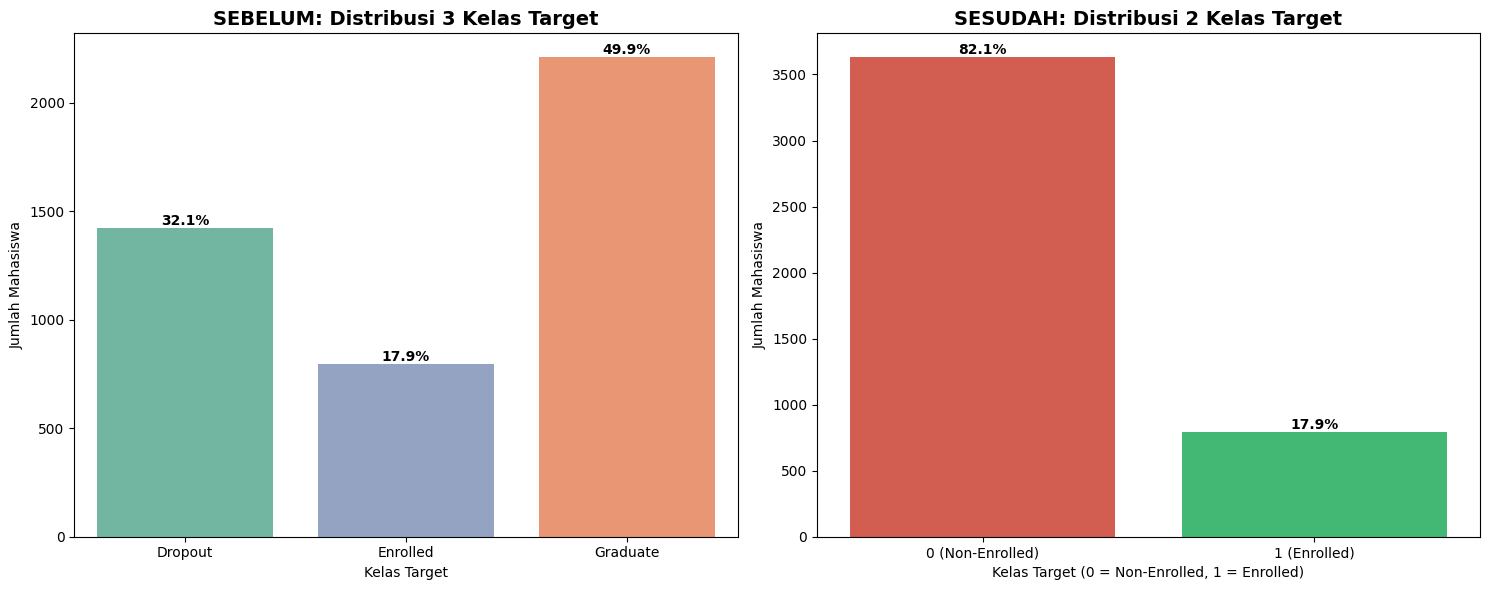

In [2]:
# =========================================================
# SEL 2: TRANSFORMASI TARGET & VISUALISASI BEFORE-AFTER
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# COPY TARGET ASLI UNTUK VISUALISASI
# ---------------------------------------------------------
df['Target_Original'] = df['Target']

# ---------------------------------------------------------
# TRANSFORMASI TARGET BINARY
# 0 = Dropout & Graduate
# 1 = Enrolled
# ---------------------------------------------------------
df['Target_Kelas'] = df['Target_Original'].apply(
    lambda x: 1 if x == 'Enrolled' else 0
)

# ---------------------------------------------------------
# SETUP PLOT
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# =========================================================
# GRAFIK 1: SEBELUM (3 KELAS)
# =========================================================
sns.countplot(
    data=df,
    x='Target_Original',
    hue='Target_Original', 
    palette='Set2',
    ax=axes[0],
    order=['Dropout', 'Enrolled', 'Graduate'],
    legend=False         
)

axes[0].set_title('SEBELUM: Distribusi 3 Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kelas Target')
axes[0].set_ylabel('Jumlah Mahasiswa')

# Tambah persentase
total = len(df)
for p in axes[0].patches:
    axes[0].annotate(
        f'{100 * p.get_height() / total:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# =========================================================
# GRAFIK 2: SESUDAH (2 KELAS TARGET)
# =========================================================
sns.countplot(
    data=df,
    x='Target_Kelas',
    hue='Target_Kelas',    
    palette=['#e74c3c', '#2ecc71'],
    ax=axes[1],
    legend=False         
)

axes[1].set_title('SESUDAH: Distribusi 2 Kelas Target', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kelas Target (0 = Non-Enrolled, 1 = Enrolled)')
axes[1].set_ylabel('Jumlah Mahasiswa')

axes[1].set_xticks([0, 1], labels=['0 (Non-Enrolled)', '1 (Enrolled)'])

# Tambah persentase
for p in axes[1].patches:
    axes[1].annotate(
        f'{100 * p.get_height() / total:.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# ---------------------------------------------------------
# FINAL LAYOUT
# ---------------------------------------------------------
plt.tight_layout()
plt.show()

# =========================================================
# CLEANING UNTUK MODELING
# =========================================================

df = df.drop(columns=['Target', 'Target_Original'])
df = df.rename(columns={'Target_Kelas': 'Target'})

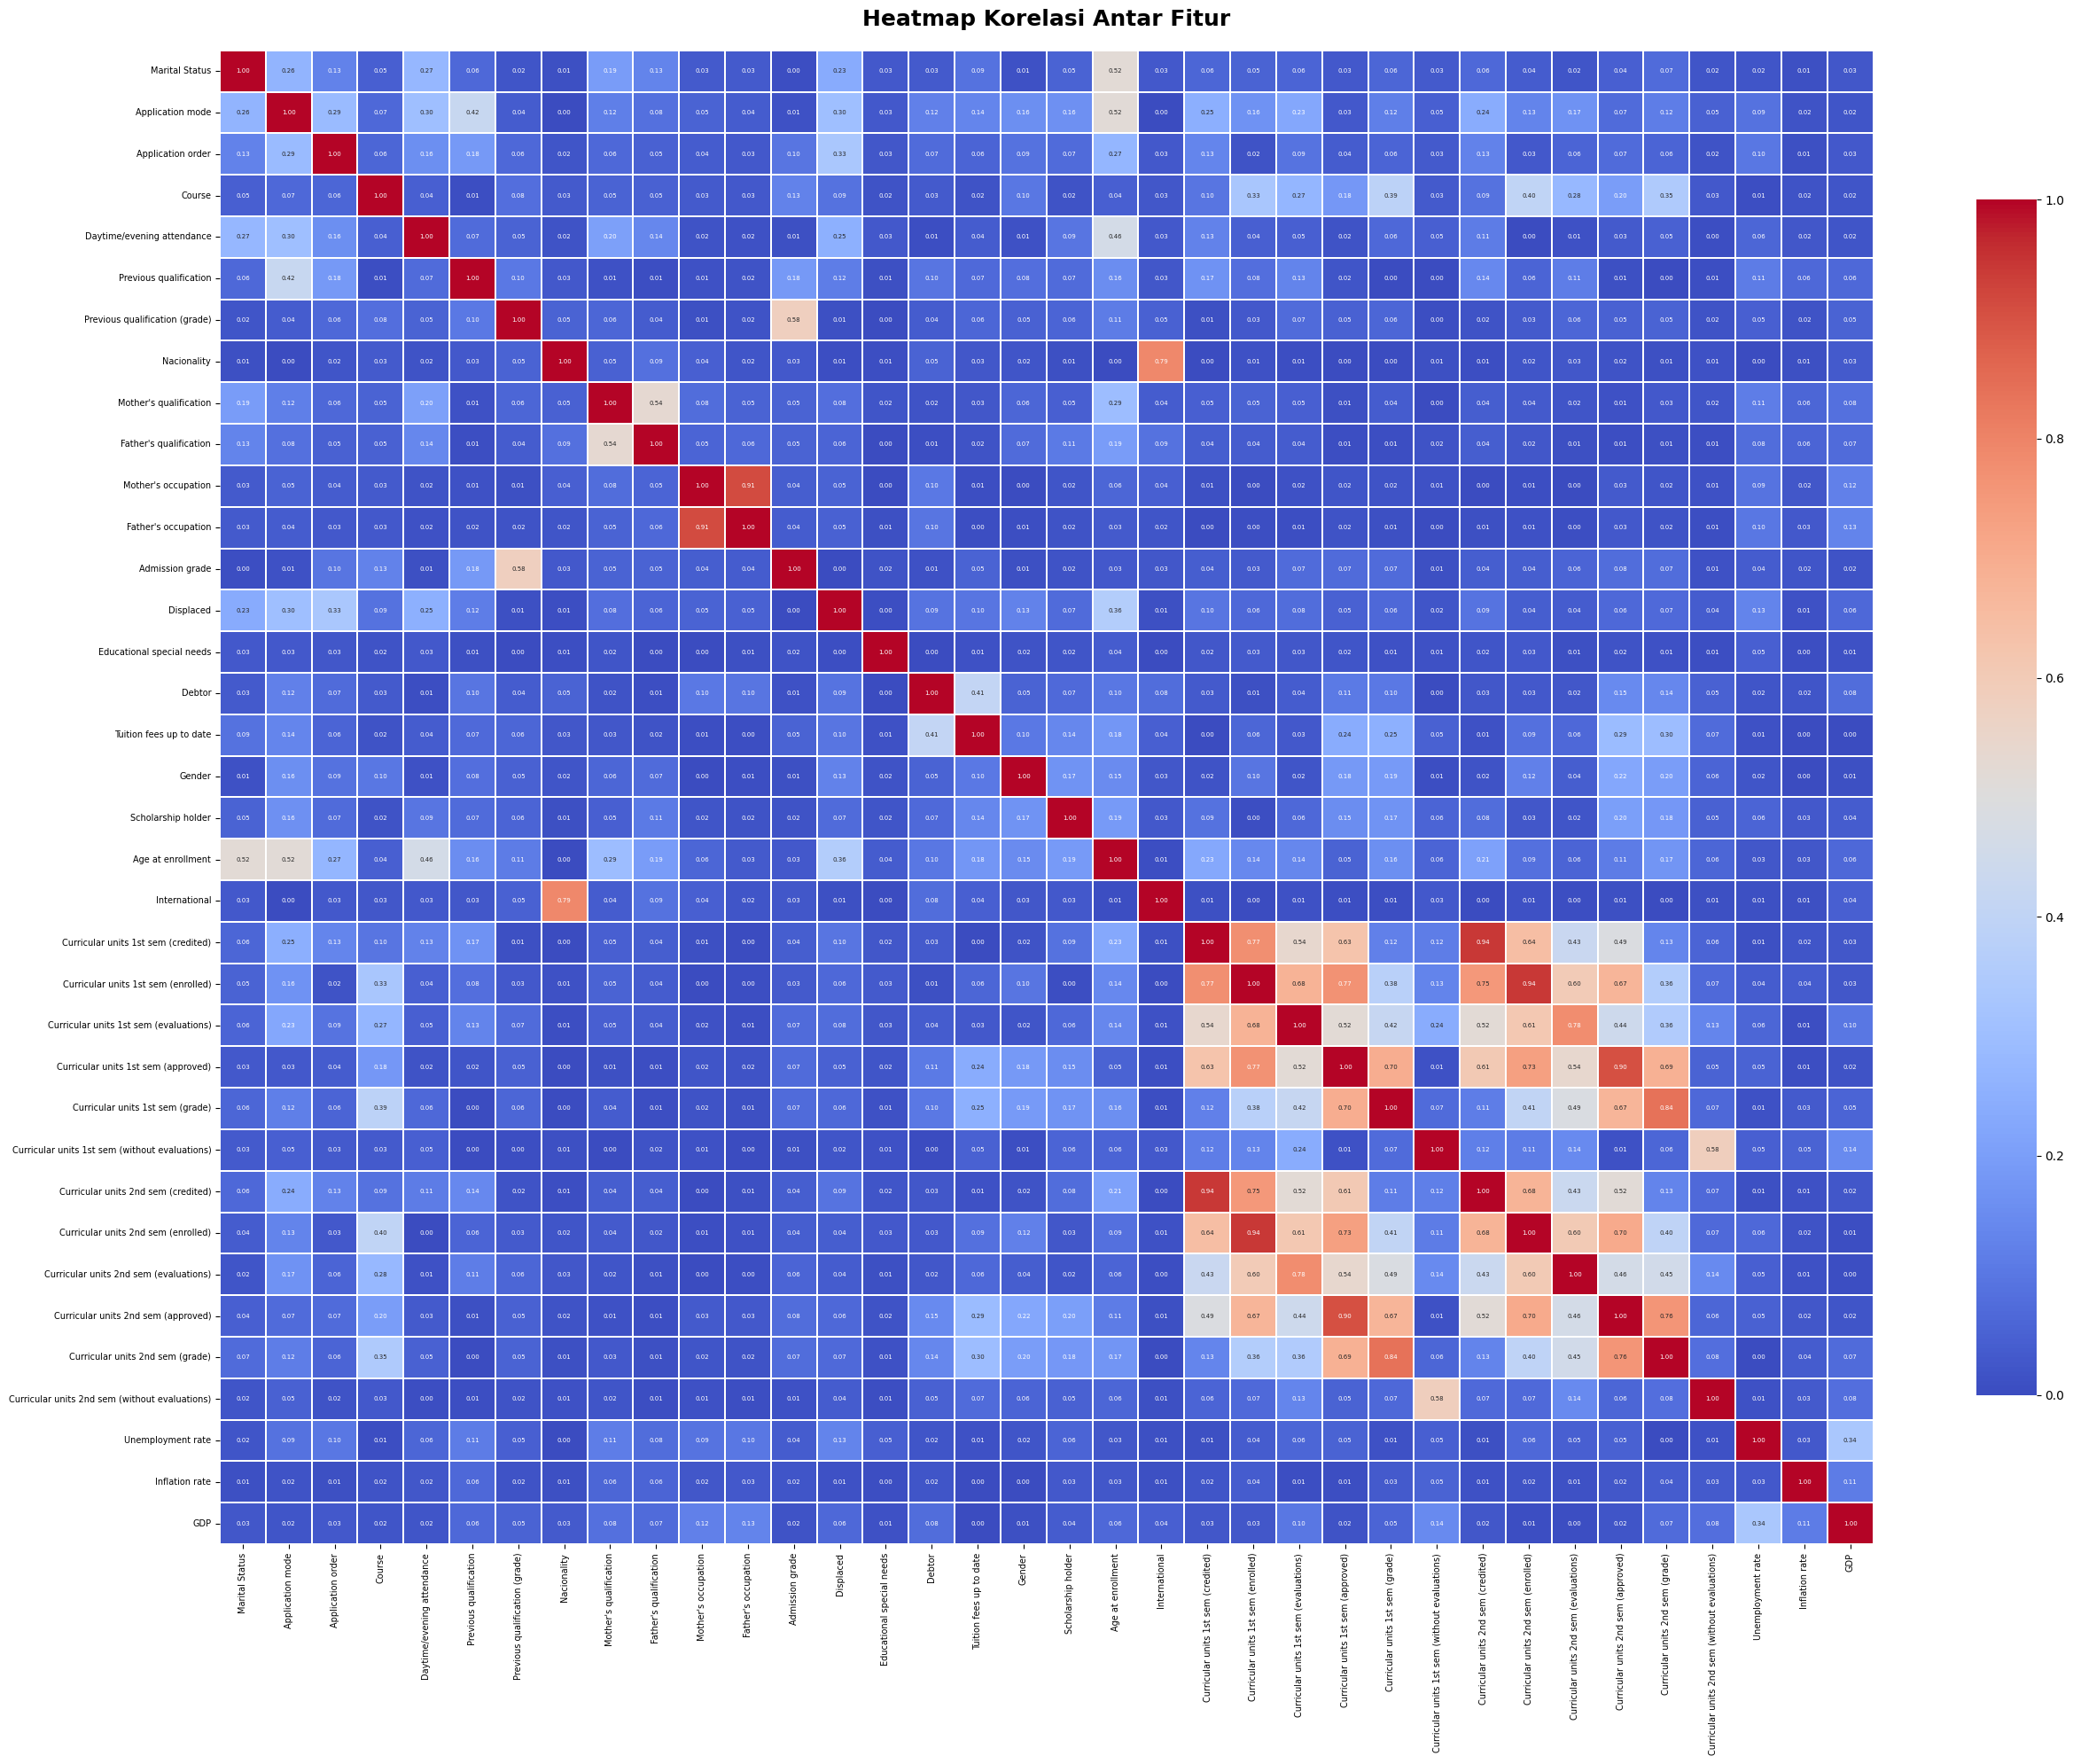


Fitur dengan korelasi > 0.85 (akan dihapus):

- Father's occupation
- Curricular units 2nd sem (credited)
- Curricular units 2nd sem (enrolled)
- Curricular units 2nd sem (approved)

Dimensi dataset:
- Sebelum : (4424, 37)
- Sesudah : (4424, 33)


In [3]:
# =========================================================
# SEL 3: KORELASI & FEATURE REDUCTION
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CORRELATION_THRESHOLD = 0.85

# =========================================================
# SPLIT DATA (TEMPORARY FEATURE SET)
# =========================================================
X_temp = df.drop(columns=['Target'])

# Korelasi absolut antar fitur
corr_matrix = X_temp.corr().abs()

# =========================================================
# VISUALISASI HEATMAP KORELASI (FULL + RAPI)
# =========================================================
plt.figure(figsize=(26, 20))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    annot=True,          # ✔ angka ditampilkan
    fmt=".2f",           # 2 desimal biar rapi
    annot_kws={"size": 5},
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)

plt.title('Heatmap Korelasi Antar Fitur', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

# =========================================================
# DETEKSI FITUR KORELASI TINGGI
# =========================================================

# Ambil upper triangle untuk menghindari duplikasi
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identifikasi fitur yang redundant
to_drop = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] > CORRELATION_THRESHOLD)
]

# =========================================================
# OUTPUT INSIGHT
# =========================================================
print(f"\nFitur dengan korelasi > {CORRELATION_THRESHOLD} (akan dihapus):\n")

if len(to_drop) > 0:
    for col in to_drop:
        print(f"- {col}")
else:
    print("- Tidak ada fitur yang melewati threshold")

# =========================================================
# FEATURE REDUCTION
# =========================================================
df_cleaned = df.drop(columns=to_drop)

print("\nDimensi dataset:")
print(f"- Sebelum : {df.shape}")
print(f"- Sesudah : {df_cleaned.shape}")

# =========================================================
# FINAL DATASET FOR MODELING
# =========================================================
X = df_cleaned.drop(columns=['Target'])
y = df_cleaned['Target']

In [4]:
# =========================================================
# SEL 4: TRAIN-TEST SPLIT & FEATURE SCALING
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================================================
# TRAIN-TEST SPLIT (STRATIFIED 80:20)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# FEATURE SCALING (STANDARDIZATION)
# =========================================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# BASIC CHECK
# =========================================================
feature_names = X.columns

print("Data splitting selesai")
print(f"- Jumlah data train : {len(X_train)}")
print(f"- Jumlah data test  : {len(X_test)}")
print(f"- Jumlah fitur      : {len(feature_names)}")

Data splitting selesai
- Jumlah data train : 3539
- Jumlah data test  : 885
- Jumlah fitur      : 32


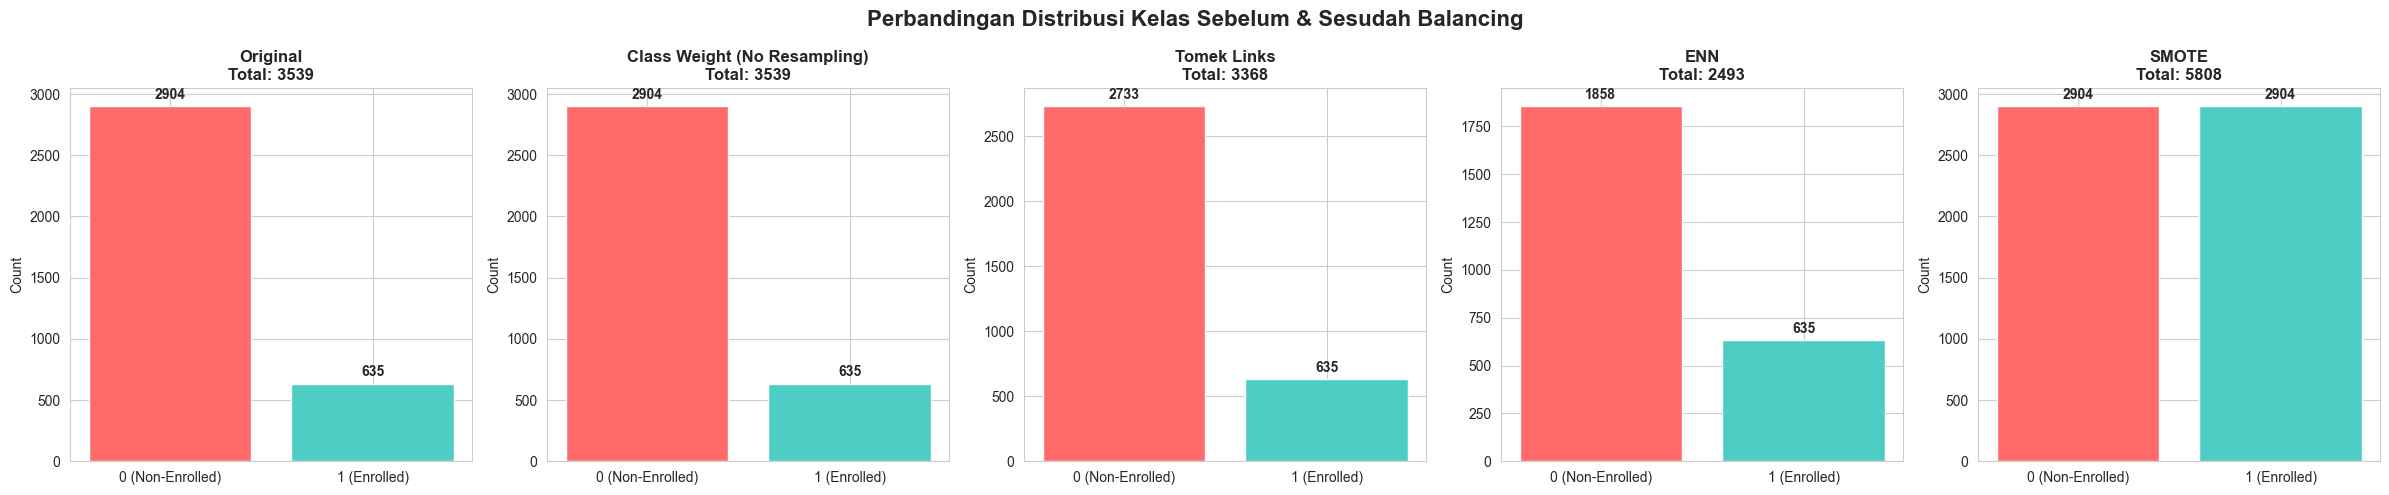


Distribusi kelas (awal):
Target
0    0.820571
1    0.179429
Name: proportion, dtype: float64


In [5]:
# =========================================================
# SEL 5: IMBALANCE HANDLING & MODEL TRAINING
# =========================================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================================================
# MODEL CONTAINER
# =========================================================
models = {}

# =========================================================
# 1. BASELINE MODEL
# =========================================================
gb_baseline = GradientBoostingClassifier(random_state=42)
gb_baseline.fit(X_train_scaled, y_train)
models['Baseline'] = gb_baseline

# =========================================================
# 2. CLASS WEIGHT
# =========================================================
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_weighted = GradientBoostingClassifier(random_state=42)
gb_weighted.fit(X_train_scaled, y_train, sample_weight=sample_weights)
models['Class Weight'] = gb_weighted

# =========================================================
# 3. TOMEK LINKS
# =========================================================
tl = TomekLinks()
X_train_tl, y_train_tl = tl.fit_resample(X_train_scaled, y_train)

gb_tomek = GradientBoostingClassifier(random_state=42)
gb_tomek.fit(X_train_tl, y_train_tl)
models['Tomek Links'] = gb_tomek

# =========================================================
# 4. ENN
# =========================================================
enn = EditedNearestNeighbours()
X_train_enn, y_train_enn = enn.fit_resample(X_train_scaled, y_train)

gb_enn = GradientBoostingClassifier(random_state=42)
gb_enn.fit(X_train_enn, y_train_enn)
models['ENN'] = gb_enn

# =========================================================
# 5. SMOTE
# =========================================================
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

gb_smote = GradientBoostingClassifier(random_state=42)
gb_smote.fit(X_train_smote, y_train_smote)
models['SMOTE'] = gb_smote

# =========================================================
# VISUALISASI DISTRIBUSI KELAS (IMPROVED VERSION)
# =========================================================

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

datasets = [
    ("Original", y_train),
    ("Class Weight (No Resampling)", y_train),
    ("Tomek Links", y_train_tl),
    ("ENN", y_train_enn),
    ("SMOTE", y_train_smote)
]

colors = ["#ff6b6b", "#4ecdc4"]

for i, (title, data) in enumerate(datasets):
    counts = np.bincount(data)

    axes[i].bar(["0 (Non-Enrolled)", "1 (Enrolled)"], counts, color=colors)

    axes[i].set_title(f"{title}\nTotal: {len(data)}", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Count")

    # Annotate value
    for j, v in enumerate(counts):
        axes[i].text(j, v + 0.02 * max(counts), str(v),
                     ha='center', fontweight='bold', fontsize=10)

plt.suptitle("Perbandingan Distribusi Kelas Sebelum & Sesudah Balancing",
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# =========================================================
# IMBALANCE RATIO CHECK (IMPORTANT FOR Q&A)
# =========================================================

ratio = y_train.value_counts(normalize=True)
print("\nDistribusi kelas (awal):")
print(ratio)

##TOMEK LINKS
1.Pengertian Tomek Links
Tomek Links adalah teknik undersampling untuk menangani data tidak seimbang (imbalanced data) dengan cara membersihkan titik data dari kelas mayoritas yang posisinya menempel atau tumpang tindih dengan data kelas minoritas. Tujuannya adalah mempertegas batas pemisah antar kelas agar model tidak kebingungan.

2.Rumus dan Cara Kerja (Contoh Matematis)
Tomek Links mendeteksi tumpang tindih dengan mencari tetangga terdekat menggunakan Jarak Euclidean:
$$
d=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$

Skenario Data (Fitur SKS & Nilai):
	A (Mayoritas/Nonaktif): SKS = 10, Nilai = 10
	B (Minoritas/Aktif): SKS = 12, Nilai = 11
	C (Mayoritas/Nonaktif): SKS = 13, Nilai = 14
Perhitungan Jarak:

$$
d(A,B)=\sqrt{(2)^2+(1)^2}=2.23
$$

$$
d(B,C)=\sqrt{(1)^2+(3)^2}=3.16
$$

$$
d(A,C)=\sqrt{(3)^2+(4)^2}=5.00
$$

Cara Kerja: Karena Mahasiswa A dan B saling menjadi tetangga terdekat (jarak terkecil 2.23) namun mereka berbeda kelas, keduanya resmi membentuk pasangan Tomek Link. Sesuai aturan untuk mengatasi ketidakseimbangan data, data kelas mayoritas (A) langsung dihapus dari dataset, sedangkan B dan C tetap dipertahankan.

3.Dampak pada Hasil dan Visualisasi
Penghapusan data noise di daerah perbatasan (seperti Mahasiswa A) membuat batas (decision boundary) antara kelas "Aktif" dan "Nonaktif" menjadi sangat bersih. Hasilnya, saat model Gradient Boosting dilatih, model terhindar dari overfitting. Secara visual pada perbandingan grafik, batang kelas mayoritas akan sedikit berkurang jumlahnya, namun kemampuan model dalam mendeteksi kelas minoritas akan meningkat secara signifikan.
Peningkatan ini sangat menjawab fokus utama pada penelitian saya ini, yang menjadikan Macro F1-Score sebagai tolok ukur utama evaluasi model. Pada data yang tidak seimbang, nilai Macro F1-Score memberikan bobot evaluasi yang adil untuk kedua kelas. Pencapaian Macro F1-Score yang optimal menjadi bukti nyata bahwa model berhasil mengenali mahasiswa "Aktif" dengan presisi, bukan sekadar bias menebak kelas mayoritas "Nonaktif".



## Class Wight

1. **Pengertian Class Weight (CW)**  
Class Weight (CW) merupakan pendekatan *cost-sensitive learning* yang digunakan untuk mengatasi permasalahan ketidakseimbangan kelas (*class imbalance*) pada data klasifikasi. Ketidakseimbangan kelas terjadi ketika jumlah sampel antar kelas tidak seimbang, sehingga model cenderung lebih dominan mempelajari kelas mayoritas dan kurang optimal dalam mengenali kelas minoritas. Kondisi ini berdampak pada penurunan performa model, terutama pada metrik recall dan F1-score. Dalam penelitian ini, Class Weight digunakan tanpa mengubah distribusi data, melainkan dengan memberikan bobot berbeda pada setiap kelas agar kontribusi masing-masing kelas dalam proses pembelajaran menjadi lebih seimbang.

2. **Rumus dan Cara Kerja Class Weight**  
Secara matematis, bobot kelas dirumuskan sebagai:

$$
w_c = \frac{N}{K \cdot n_c}
$$

Dengan keterangan:
- $w_c$ = bobot kelas ke-c  
- $N$ = total seluruh data training  
- $K$ = jumlah kelas  
- $n_c$ = jumlah sampel pada kelas ke-c  

Bobot ini bersifat berbanding terbalik dengan jumlah sampel, sehingga kelas minoritas akan memiliki bobot lebih besar dibandingkan kelas mayoritas.

Dalam fungsi loss standar:

$$
L = \sum_{i=1}^{N} \ell(y_i, \hat{y}_i)
$$

Ketika Class Weight diterapkan, fungsi loss berubah menjadi:

$$
L = \sum_{i=1}^{N} w_{y_i} \cdot \ell(y_i, \hat{y}_i)
$$

Keterangan:
- $y_i$ = label aktual data ke-i  
- $\hat{y}_i$ = hasil prediksi model  
- $w_{y_i}$ = bobot kelas dari data ke-i  
- $\ell$ = fungsi loss (misalnya cross-entropy atau log loss)  

Dengan mekanisme ini, kesalahan pada kelas minoritas akan memberikan penalti lebih besar dibandingkan kelas mayoritas, sehingga proses optimisasi menjadi lebih sensitif terhadap kelas yang jarang muncul.

3. **Dampak terhadap Model dan Evaluasi**  
Penerapan Class Weight membuat model lebih fokus pada kelas minoritas selama proses training, sehingga decision boundary menjadi lebih seimbang antara kelas mayoritas dan minoritas. Dampaknya, kemampuan model dalam mengenali kelas minoritas meningkat yang tercermin dari kenaikan recall. Namun, precision dapat sedikit menurun karena meningkatnya jumlah prediksi positif.

Secara keseluruhan, F1-score dapat meningkat apabila kenaikan recall lebih dominan dibandingkan penurunan precision. Dibandingkan metode lain seperti SMOTE, ENN, dan Tomek Links, Class Weight tidak mengubah distribusi data, melainkan hanya memodifikasi fungsi loss. Hal ini membuatnya lebih stabil, efisien, dan tidak menimbulkan risiko distorsi data akibat sampling ulang.

## **SMOTE**
1. **Pengertian Smote**  
SMOTE (*Synthetic Minority Over-sampling Technique*) merupakan metode **oversampling** yang digunakan untuk mengatasi masalah **ketidakseimbangan data (*imbalanced data*)** dengan cara membuat **data sintetis (*synthetic data*)** pada kelas minoritas.
Berbeda dengan oversampling biasa yang hanya menggandakan data yang sudah ada (*duplicate sampling*), SMOTE menghasilkan sampel baru berdasarkan interpolasi antara data minoritas dengan tetangga terdekatnya (*nearest neighbors*). Dengan demikian, distribusi kelas menjadi lebih seimbang tanpa hanya menyalin data yang sama. Pada penelitian ini, SMOTE digunakan untuk menyeimbangkan jumlah mahasiswa **Aktif (*Enrolled*)** yang merupakan kelas minoritas terhadap mahasiswa **Nonaktif (*Graduate + Dropout*)** sebelum model **Gradient Boosting** dilatih.
2. **Rumus dan Cara Kerja Smote**  
SMOTE membentuk data sintetis menggunakan persamaan interpolasi:
$$x_{baru} = x_i + \lambda (x_{nn} - x_i)$$
Keterangan:


*   $x_i$ = data minoritasi yang dipilih
*   $x_{nn}$ = salah satu tetangga terdekat dari kelas minoritas
*   $\lambda$ = bilangan acak antara 0 dan 1
*   $x_{baru}$ = data sintesis yang dihasilkan

Nilai $\lambda$ dipilih secara acak sehingga data baru berada di antara dua titik data minoritas.

Proses kerja SMOTE dilakukan melalui beberapa tahap berikut.


*   Memilih satu sampel dari kelas minoritas.

     Contoh: Mahasiswa Aktif A (SKS=10, Nilai=80)
*   Menentukan k-nearest neighbors (biasanya k = 5) menggunakan jarak Euclidean.

     Rumus jarak Euclidean:
     
     $$d = \sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}$$
     Keterangan:
     * $d$ = jarak Euclidean antara dua titik data
     * $x_i$ = nilai fitur ke-$i$ pada data pertama
     * $y_i$ = nilai fitur ke-$i$ pada data kedua
     * $n$ = jumlah fitur atau dimensi data
     
     Tetangga dengan jarak terdekat dipilih sebagai dasar pembentukan data sintetis.
*   Menghasilkan nilai acak
     $$0 \leq \lambda \leq 1$$
*   Membuat data baru menggunakan rumus interpolasi
     $$x_{baru} = x_i + \lambda (x_{nn} - x_i)$$
*   Mengulangi proses hingga jumlah kelas minoritas menjadi seimbang dengan kelas mayoritas.
3. **Dampak Smote terhadap Model**

   Penerapan SMOTE (*Synthetic Minority Over-sampling Technique*) membuat distribusi data menjadi lebih seimbang dengan menambahkan data sintetis pada kelas minoritas. Kondisi ini membantu model **Gradient Boosting** mempelajari karakteristik kedua kelas secara lebih adil sehingga mengurangi bias terhadap kelas mayoritas dan menghasilkan decision boundary yang lebih baik. Dampaknya, kemampuan model dalam mengenali kelas minoritas meningkat, yang umumnya ditunjukkan oleh kenaikan nilai **Recall** dan **Macro F1-Score**. Meskipun **Precision** atau **Accuracy** dapat mengalami sedikit perubahan akibat bertambahnya prediksi pada kelas minoritas, secara keseluruhan performa model menjadi lebih seimbang dan lebih representatif dalam mengklasifikasikan kedua kelas, terutama pada kasus data yang tidak seimbang.



## ENN (Edited Nearest Neighbours)

**1. Pengertian ENN**

ENN adalah teknik undersampling untuk menangani data tidak seimbang (imbalanced data) dengan cara membersihkan data dari kelas mayoritas yang berada di sekitar wilayah kelas minoritas. Berbeda dengan Tomek Links yang hanya menghapus pasangan data yang saling bertetangga dan berbeda kelas, ENN memeriksa k tetangga terdekat (umumnya k = 3) dari setiap sampel, kemudian menghapus sampel apabila label mayoritas dari tetangganya tidak sama dengan label sampel itu sendiri.

Tujuannya adalah membuat batas antar kelas menjadi lebih bersih dan mengurangi noise atau tumpang tindih data di wilayah perbatasan.

**2. Rumus dan Cara Kerja ENN**

ENN mendeteksi kecocokan label menggunakan tetangga terdekat berdasarkan Jarak Euclidean:

$$
d(x_i, x_j) = \sqrt{\sum_{f=1}^{n}(x_{i,f}-x_{j,f})^2}
$$

Aturan penghapusan data untuk setiap titik data $x_i$ dengan label $y_i$:

$$
\text{Hapus } x_i \text{ jika } \text{mode}(y_{NN_1}, y_{NN_2}, ..., y_{NN_k}) \neq y_i
$$

Keterangan:

- $k$ = jumlah tetangga terdekat (umumnya 3)
- $y_{NN_1}, ..., y_{NN_k}$ = label dari k tetangga terdekat $x_i$
- mode(...) = label mayoritas di antara k tetangga

Skenario Data (Fitur SKS & Nilai), k = 3:

- Mahasiswa A (Mayoritas/Nonaktif): SKS = 10, Nilai = 10
- Tiga tetangga terdekat A: dua berlabel Aktif, satu berlabel Nonaktif
- mode dari tetangga = Aktif, sedangkan label asli A = Nonaktif
- Karena tidak cocok, maka data A dihapus dari dataset

Sebaliknya, jika tetangga terdekat suatu data mayoritas berlabel sama (Nonaktif), maka data tersebut dipertahankan. Proses ini diulang untuk seluruh data kelas mayoritas sehingga titik-titik yang berada di zona tumpang tindih dengan kelas minoritas ikut tersaring dari dataset.

**3. Dampak ENN terhadap Model**

Berdasarkan hasil eksperimen pada penelitian ini, performa model dengan teknik ENN adalah sebagai berikut:

| Metrik | Nilai |
|---|---|
| Accuracy | 0.7910 |
| Macro F1-Score | 0.6699 |
| Macro Precision | 0.6604 |
| Macro Recall | 0.6835 |

Penerapan ENN membuat data kelas mayoritas yang berada di sekitar wilayah kelas minoritas terhapus, sehingga decision boundary antara kelas Aktif dan Nonaktif menjadi lebih tegas. Dampaknya, model Gradient Boosting menjadi lebih sensitif dalam mengenali kelas minoritas, tercermin dari nilai recall yang meningkat dibandingkan model Baseline dan Tomek Links.

Dibandingkan empat teknik lain yang diuji (Baseline, Class Weight, Tomek Links, dan SMOTE), ENN menghasilkan Macro F1-Score tertinggi yaitu 0.6699, meskipun nilai accuracy-nya bukan yang paling tinggi. Hal ini menunjukkan bahwa ENN memberikan keseimbangan terbaik antara precision dan recall pada kedua kelas, sesuai dengan fokus penelitian yang menjadikan Macro F1-Score sebagai metrik evaluasi utama.

Karena performa terbaiknya, model ENN dipilih sebagai model akhir dalam penelitian ini untuk dianalisis lebih lanjut menggunakan SHAP (SHapley Additive Explanations) guna mengidentifikasi fitur-fitur yang paling berpengaruh terhadap status keaktifan mahasiswa.

=== MODEL PERFORMANCE COMPARISON ===


,Model,Accuracy,Macro F1,Macro Precision,Macro Recall
3,ENN,0.790960,0.669862,0.660394,0.683481
4,SMOTE,0.803390,0.654471,0.660624,0.649306
1,Class Weight,0.738983,0.651188,0.641394,0.708288
2,Tomek Links,0.832768,0.635584,0.715062,0.613182
0,Baseline,0.831638,0.588982,0.726279,0.575654


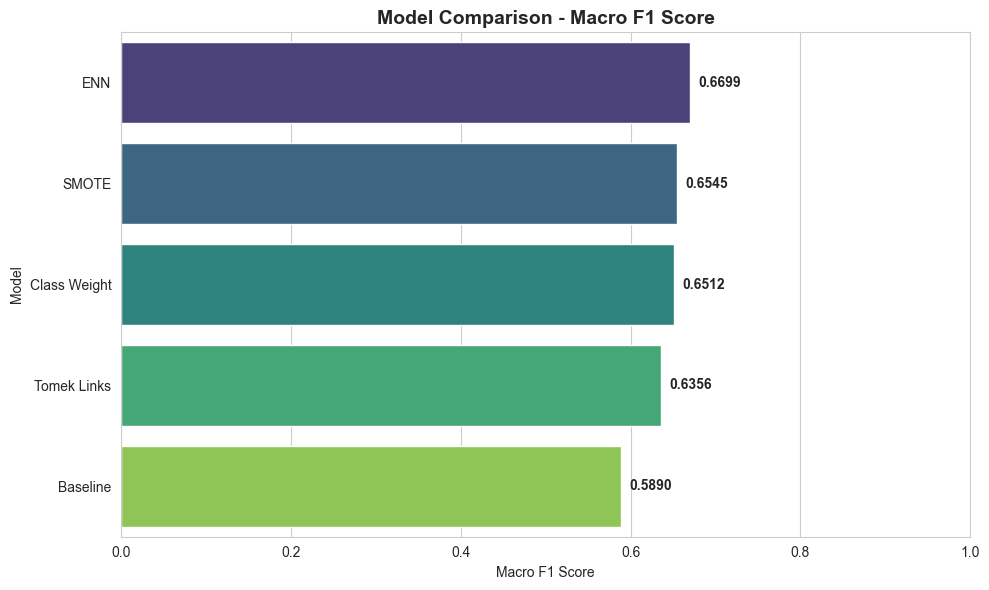

In [6]:
# =========================================================
# SEL 6: MODEL EVALUATION & COMPARISON
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# EVALUATION STORAGE
# =========================================================
evaluation_results = []

# =========================================================
# EVALUATE ALL MODELS
# =========================================================
for name, model in models.items():

    y_pred = model.predict(X_test_scaled)

    evaluation_results.append([
        name,
        accuracy_score(y_test, y_pred),
        f1_score(y_test, y_pred, average='macro'),
        precision_score(y_test, y_pred, average='macro'),
        recall_score(y_test, y_pred, average='macro')
    ])

# =========================================================
# CREATE RESULT TABLE
# =========================================================
df_eval = pd.DataFrame(
    evaluation_results,
    columns=['Model', 'Accuracy', 'Macro F1', 'Macro Precision', 'Macro Recall']
)

df_eval = df_eval.sort_values(by='Macro F1', ascending=False)

print("=== MODEL PERFORMANCE COMPARISON ===")
display(df_eval)

# =========================================================
# VISUAL COMPARISON: MACRO F1 SCORE
# =========================================================

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_eval,
    x='Macro F1',
    y='Model',
    hue='Model',       
    palette='viridis',
    legend=False      
)

plt.title('Model Comparison - Macro F1 Score', fontsize=14, fontweight='bold')
plt.xlabel('Macro F1 Score')
plt.ylabel('Model')
plt.xlim(0, 1)

# =========================================================
# ANNOTATION (VALUE ON BAR)
# =========================================================
for p in ax.patches:
    ax.text(
        p.get_width() + 0.01,
        p.get_y() + p.get_height() / 2,
        f"{p.get_width():.4f}",
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

=== SHAP FEATURE ANALYSIS ===
Best Model Selected: ENN


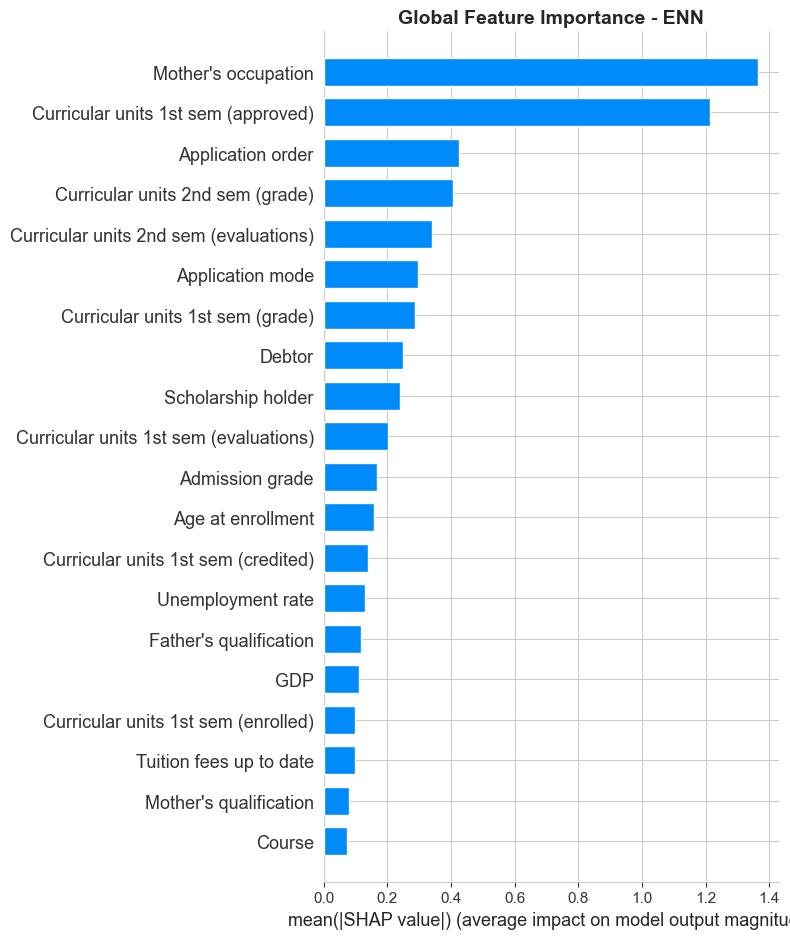

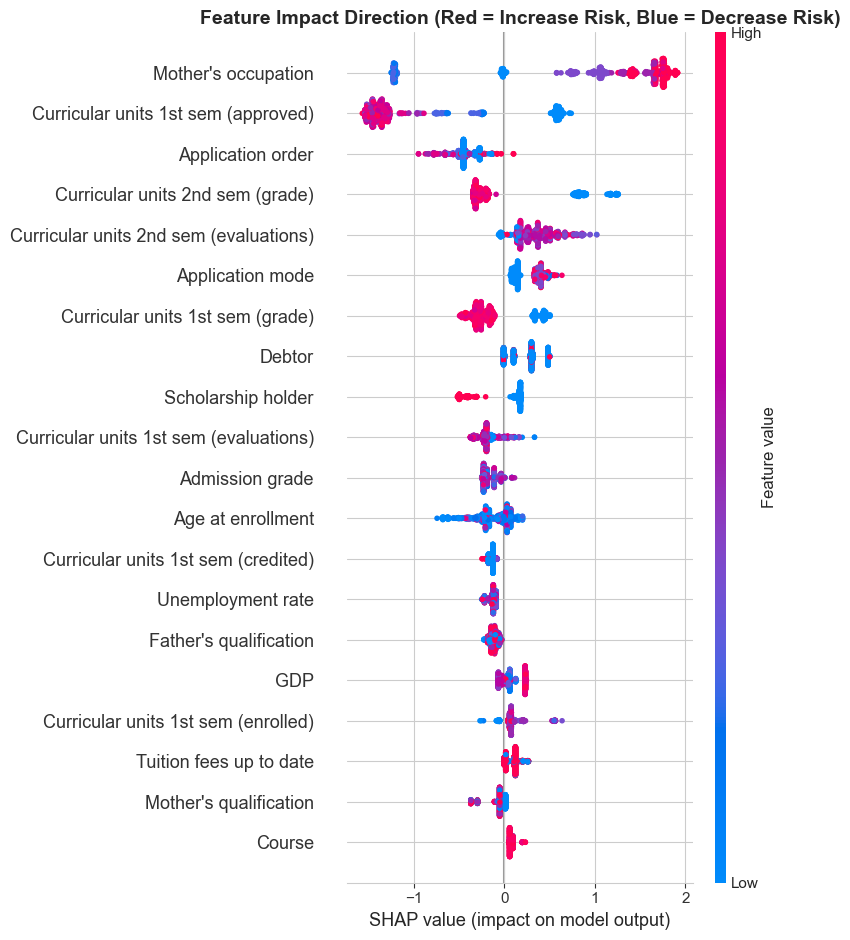

In [7]:
# =========================================================
# SEL 7: FEATURE INTERPRETATION (SHAP ANALYSIS)
# =========================================================

import shap
import matplotlib.pyplot as plt

# =========================================================
# SELECT BEST MODEL (BASED ON F1 SCORE)
# =========================================================
best_model_name = df_eval.sort_values(
    by='Macro F1',
    ascending=False
).iloc[0]['Model']

best_model = models[best_model_name]

print("=== SHAP FEATURE ANALYSIS ===")
print(f"Best Model Selected: {best_model_name}")

# =========================================================
# IMPORTANT NOTE:
# SHAP lebih stabil jika pakai data original (tanpa scaling)
# untuk tree-based model
# =========================================================
X_shap = X_test  # gunakan data asli (bukan scaled)

# =========================================================
# SHAP EXPLAINER
# =========================================================
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# =========================================================
# 1. FEATURE IMPORTANCE (GLOBAL IMPACT)
# =========================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title(
    f"Global Feature Importance - {best_model_name}",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# =========================================================
# 2. SHAP SUMMARY PLOT (DIRECTIONAL IMPACT)
# =========================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)

plt.title(
    "Feature Impact Direction (Red = Increase Risk, Blue = Decrease Risk)",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

**Analisis SHAP Feature Importance**

**`Analisis Global Feature Importance`**

Berdasarkan hasil analisis SHAP (SHapley Additive Explanations), diperoleh informasi mengenai kontribusi masing-masing fitur terhadap keputusan model ENN dalam memprediksi status mahasiswa. Nilai mean(|SHAP value|) digunakan untuk mengukur tingkat pengaruh suatu fitur terhadap output model. Semakin besar nilai tersebut, semakin besar pula kontribusi fitur dalam menentukan hasil prediksi.

Hasil visualisasi menunjukkan bahwa Mother's Occupation merupakan fitur yang memiliki pengaruh paling besar terhadap keputusan model, diikuti oleh Curricular Units 1st Semester (Approved), Application Order, Curricular Units 2nd Semester (Grade), dan Curricular Units 1st Semester (Grade). Dominasi fitur-fitur tersebut menunjukkan bahwa model lebih banyak mempertimbangkan faktor sosial ekonomi keluarga serta performa akademik pada tahun pertama dibandingkan faktor lainnya.

Menariknya, variabel yang berkaitan dengan kondisi ekonomi makro seperti GDP dan Unemployment Rate memiliki tingkat kontribusi yang relatif rendah. Hal ini mengindikasikan bahwa karakteristik individu mahasiswa dan kondisi keluarganya lebih berpengaruh terhadap status akademik dibandingkan kondisi ekonomi secara umum.

Secara keseluruhan, hasil feature importance menunjukkan bahwa prediksi status mahasiswa tidak hanya dipengaruhi oleh kemampuan akademik, tetapi juga dipengaruhi oleh faktor lingkungan keluarga, motivasi saat proses pendaftaran, serta kondisi finansial mahasiswa.

**Analisis Fitur Dominan**


**`A. Mother's Occupation`**

Mother's Occupation merupakan fitur dengan nilai importance tertinggi pada model. Hasil ini menunjukkan bahwa pekerjaan ibu memiliki hubungan yang kuat terhadap status mahasiswa. Variabel ini dapat merepresentasikan kondisi sosial ekonomi keluarga, stabilitas finansial rumah tangga, tingkat dukungan terhadap pendidikan, serta lingkungan belajar yang diterima mahasiswa sejak sebelum memasuki perguruan tinggi.

Besarnya pengaruh fitur ini mengindikasikan bahwa keberhasilan studi mahasiswa tidak hanya ditentukan oleh faktor akademik semata, tetapi juga dipengaruhi oleh kondisi keluarga. Mahasiswa yang berasal dari keluarga dengan dukungan sosial dan ekonomi yang lebih baik cenderung memiliki peluang lebih besar untuk menyelesaikan studi dengan baik dibandingkan mahasiswa yang menghadapi keterbatasan sumber daya keluarga.


**`B. Curricular Units 1st Semester (Approved)`**

Fitur ini menunjukkan jumlah mata kuliah yang berhasil diselesaikan mahasiswa pada semester pertama. Tingginya nilai importance pada fitur ini menunjukkan bahwa performa akademik awal merupakan indikator yang sangat kuat dalam memprediksi status mahasiswa.

Semester pertama merupakan masa adaptasi terhadap lingkungan perkuliahan. Mahasiswa yang mampu menyelesaikan lebih banyak mata kuliah pada periode ini cenderung menunjukkan kemampuan beradaptasi yang baik terhadap sistem pembelajaran di perguruan tinggi. Sebaliknya, mahasiswa yang mengalami banyak kegagalan pada semester pertama memiliki risiko lebih tinggi mengalami kesulitan akademik pada semester berikutnya.

Temuan ini menunjukkan bahwa semester pertama dapat digunakan sebagai periode penting untuk melakukan identifikasi dini terhadap mahasiswa yang berpotensi mengalami permasalahan akademik.

**`C. Application Order`**

Application Order menggambarkan urutan pilihan program studi saat proses pendaftaran. Hasil analisis menunjukkan bahwa fitur ini memiliki kontribusi yang cukup besar terhadap keputusan model.

Secara konseptual, mahasiswa yang menjadikan suatu program studi sebagai pilihan utama biasanya memiliki motivasi, minat, dan kesiapan yang lebih tinggi dibandingkan mahasiswa yang masuk melalui pilihan alternatif. Oleh karena itu, urutan pilihan program studi dapat menjadi indikator tidak langsung terhadap tingkat komitmen mahasiswa dalam menjalani proses perkuliahan.

Pengaruh fitur ini menunjukkan bahwa faktor motivasi sebelum memasuki perguruan tinggi masih memiliki dampak terhadap keberhasilan studi mahasiswa di masa berikutnya.

**`D. Curricular Units 2nd Semester (Grade)`**

Fitur ini merepresentasikan nilai akademik mahasiswa pada semester kedua. Tingginya kontribusi fitur ini menunjukkan bahwa kualitas performa akademik setelah masa adaptasi tetap menjadi faktor penting dalam menentukan status mahasiswa.

Mahasiswa dengan nilai akademik yang baik pada semester kedua umumnya telah berhasil menyesuaikan diri dengan sistem pembelajaran di perguruan tinggi. Sebaliknya, mahasiswa yang memperoleh nilai rendah pada semester kedua cenderung memiliki risiko yang lebih besar untuk mengalami kesulitan akademik maupun keterlambatan studi.

Hasil ini memperlihatkan bahwa keberhasilan akademik yang konsisten dari semester pertama hingga semester kedua menjadi indikator penting dalam memprediksi status mahasiswa.

**`E. Curricular Units 1st Semester (Grade)`**

Selain jumlah mata kuliah yang berhasil diselesaikan, kualitas nilai yang diperoleh mahasiswa pada semester pertama juga memberikan kontribusi yang cukup besar terhadap model.

Temuan ini menunjukkan bahwa mahasiswa yang memperoleh nilai akademik tinggi pada semester pertama cenderung memiliki peluang lebih besar untuk mempertahankan performanya pada semester berikutnya. Sebaliknya, mahasiswa dengan nilai rendah pada masa awal perkuliahan memiliki kemungkinan lebih tinggi untuk mengalami penurunan performa akademik.

Kombinasi antara jumlah mata kuliah yang lulus dan kualitas nilai yang diperoleh menjadi indikator yang sangat kuat dalam memprediksi keberhasilan studi mahasiswa.

**Analisis Feature Impact Direction**

Selain mengukur tingkat kepentingan fitur, SHAP juga digunakan untuk menganalisis arah pengaruh masing-masing fitur terhadap keputusan model melalui SHAP Summary Plot. Pada visualisasi ini, warna merah menunjukkan nilai fitur yang tinggi, sedangkan warna biru menunjukkan nilai fitur yang rendah. Posisi titik terhadap sumbu horizontal menunjukkan apakah fitur tersebut meningkatkan atau menurunkan output prediksi model.

Berdasarkan hasil visualisasi, fitur Curricular Units 1st Semester (Approved) menunjukkan pola yang sangat jelas. Nilai yang tinggi pada fitur ini cenderung menghasilkan nilai SHAP negatif, sedangkan nilai yang rendah menghasilkan nilai SHAP positif. Hal ini menunjukkan bahwa semakin banyak mata kuliah yang berhasil diselesaikan pada semester pertama, semakin kecil kemungkinan mahasiswa berada pada kategori berisiko.

Pola yang serupa juga ditemukan pada fitur Curricular Units 1st Semester (Grade) dan Curricular Units 2nd Semester (Grade). Mahasiswa yang memperoleh nilai akademik tinggi cenderung memiliki kontribusi SHAP yang mengarah pada prediksi yang lebih baik, sedangkan mahasiswa dengan nilai rendah cenderung meningkatkan risiko prediksi negatif.

Pada fitur Scholarship Holder, terlihat bahwa mahasiswa penerima beasiswa cenderung memiliki kontribusi yang mengarah pada prediksi yang lebih baik dibandingkan mahasiswa yang tidak menerima beasiswa. Temuan ini menunjukkan bahwa dukungan finansial dapat membantu mahasiswa mempertahankan keberlangsungan studinya.

Sebaliknya, fitur Debtor menunjukkan bahwa mahasiswa yang memiliki permasalahan keuangan atau tunggakan pembayaran cenderung meningkatkan risiko prediksi negatif. Kondisi finansial yang kurang stabil dapat memengaruhi fokus belajar, akses terhadap sumber daya pendidikan, maupun keberlanjutan studi mahasiswa.

Untuk fitur Mother's Occupation, terlihat bahwa kategori pekerjaan tertentu memberikan kontribusi yang jauh lebih besar dibandingkan kategori lainnya. Hasil ini memperkuat temuan sebelumnya bahwa kondisi sosial ekonomi keluarga memiliki peran penting dalam menentukan status akademik mahasiswa.

**Kesimpulan Analisis SHAP**

Berdasarkan hasil analisis SHAP, dapat disimpulkan bahwa faktor yang paling berpengaruh terhadap prediksi status mahasiswa adalah faktor sosial ekonomi keluarga dan performa akademik pada tahun pertama perkuliahan. Fitur Mother's Occupation dan Curricular Units 1st Semester (Approved) menjadi dua variabel yang memiliki kontribusi terbesar dalam model.

Hasil analisis juga menunjukkan bahwa jumlah mata kuliah yang berhasil diselesaikan serta kualitas nilai akademik pada semester pertama dan kedua merupakan indikator yang sangat kuat dalam memprediksi keberhasilan studi mahasiswa. Selain itu, faktor finansial seperti status beasiswa dan kondisi tunggakan pembayaran turut memberikan pengaruh terhadap keputusan model.

Secara keseluruhan, model menunjukkan bahwa keberhasilan studi mahasiswa lebih banyak ditentukan oleh kombinasi antara kondisi keluarga, kemampuan beradaptasi pada tahun pertama perkuliahan, dan stabilitas finansial dibandingkan faktor ekonomi makro seperti GDP maupun tingkat pengangguran. Temuan ini dapat menjadi dasar bagi institusi pendidikan untuk melakukan deteksi dini terhadap mahasiswa yang berisiko sehingga intervensi akademik maupun finansial dapat diberikan lebih cepat dan tepat sasaran.